<a href="https://colab.research.google.com/github/niuniu1fly-blip/spam-classification-project/blob/main/spam_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
#import the basic library
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

In [34]:
#import the dataset
df = pd.read_csv('spam.csv', encoding='latin-1')


In [35]:
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df['text'] = df['text'].apply(clean_text)

In [36]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [37]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [38]:
# clean the data
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\w', '', text)
    text = re.sub(r'\s+', '', text)
    words = text.split()
    words=[w for w in words if w not in stop_words]
    return ' '.join(words)


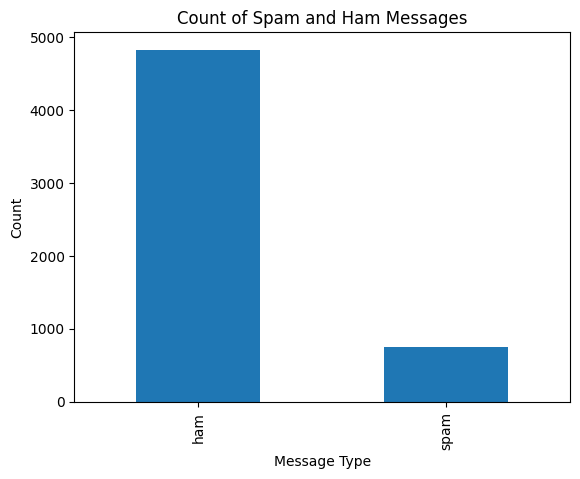

In [39]:
# count the number of spam and ham
df['label'].value_counts().plot(kind='bar')

plt.title('Count of Spam and Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

In [40]:
#creat a length column
df['length'] = df['v2'].apply(len)
#draw a histogram
plt.hist(df[df['label']=='spam']['length'], bins=50, alpha=0.7, label='spam')
plt.hist(df[df['label']=='ham']['length'], bins=50, alpha=0.7, label='ham')

plt.title('Distribution of Message Length')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend
plt.show()

KeyError: 'v2'

In [ ]:
#merge all spam texts
spam_text = ' '.join(df[df['label']=='spam']['clean_text'])

#generate a word cloud(spam)
spam_wc = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Spam Messages')
plt.show()

#generate a word cloud(ham)
ham_wc = WordCloud(width=800, height=400, background_color='white').generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Ham Messages')
plt.show()

In [ ]:
#statistics of high-frequency word


In [ ]:
print(df.head())
print(df['label'].value_counts())